# Day 2: Exploratory Data Analysis (EDA)

EDA is the process of extracting insights, hidden patterns, and relationships from data before modeling.

---

### **What is EDA? (The "Detective" Phase)**
Before building an AI, you must act like a detective. If you feed "garbage" data into a model, you will get "garbage" results. EDA helps us:
1.  **Understand the Shape:** How many rows and columns?
2.  **Find Missing Gaps:** Are there empty values (NaN)?
3.  **Spot Outliers:** Are there houses listed for $10 that shouldn't be?
4.  **Discover Relationships:** Does having a pool actually increase house price?

### **Why is EDA Important? (The "Why Bother?" Phase)**

EDA is arguably the most important step in any machine learning project. Here is why it is critical for both students and data scientists:

### 1. **"Garbage In, Garbage Out" (Data Quality)**
If you feed a model messy data, you get messy results.
```python
# Quick Check: Find "holes" (missing values)
print(df.isnull().sum().sum()) 
```

### 2. **Identifying Feature Importance**
Which features actually "matter" to the target?
```python
# Quick Check: Top 3 things that drive price
print(df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)[:4])
```

### 3. **Detecting Bias and Outliers**
Find the "weird" data points that might break your model.
```python
# Quick Check: Find houses over $600k (potential outliers)
print(df[df['SalePrice'] > 600000].shape[0])
```

### 4. **Choosing the Right Algorithm**
Linear trend vs. complex relationship.
```python
# Quick Check: Is it a straight line?
sns.regplot(x='GrLivArea', y='SalePrice', data=df, line_kws={"color": "red"})
```

### 5. **Scientific Interpretation**
Explaining "Why" the AI made a decision.
```python
# Quick Check: See how Quality directly impacts Price
print(df.groupby('OverallQual')['SalePrice'].mean())
```

**Analogy for Students:**
EDA is like **checking the ingredients** before you bake a cake. If the eggs are rotten or you're missing flour, it doesn't matter how expensive your oven (the ML model) is—the cake will be a disaster!

## 1. Dataset: Ames Housing (Real Real-Estate Data)
We use the Ames dataset, widely considered the modern successor to the Boston Housing dataset. It contains information about 1,460 houses in Ames, Iowa.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

housing = fetch_openml(name="house_prices", as_frame=True, parser='auto')
df = housing.frame
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## **Key Steps in Exploratory Data Analysis (EDA)**

Here is a 5-step checklist for EDA with mini-code snippets to use in any project:

### 1. **Data Inspection (The Overview)**
Checking the structure and summary statistics.
```python
df.shape        # Dimensions (Rows, Columns)
df.info()       # Data types and missing counts
df.describe()   # Mean, Median, Std Dev, etc.
```

### **Step 1: Inspecting the "Raw" Data**
We use `.info()` and `.describe()` to get a bird's-eye view.


In [ ]:
# Data Inspection Example
print("--- DATASET INFO ---")
print(df.info())

print("\n--- STATISTICAL SUMMARY ---")
display(df.describe()) # Shows mean, min, max, etc.


### 2. **Handling Missing Values**
Finding where the "holes" are in your data.

In [ ]:
df.isnull().sum() # List of columns with empty values

### 3. **Univariate Analysis (One Variable)**
Understanding the spread of your Target variable (e.g., Price).

<Axes: xlabel='SalePrice', ylabel='Count'>

<Axes: xlabel='SalePrice', ylabel='Count'>

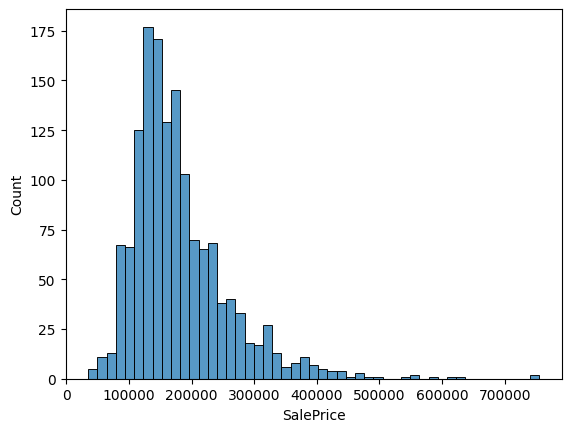

In [8]:
import seaborn as sns
sns.histplot(df['SalePrice']) # Check for skewness

### 4. **Bivariate Analysis (Two Variables)**
Checking how two variables interact.

### **Interpretation: Scatter Plot & Correlation**
*   **The Trend:** Notice how the dots move **up and to the right**. This means as the house size increases, the price also increases. This is a **Positive Correlation**.
*   **The Math (`0.708`):** A correlation of 1.0 is perfect. A score of **0.7** is very strong! It tells us that `GrLivArea` is one of the "Golden Features" that our AI should definitely use.
*   **Outliers:** Look for dots that are far away from the main "cloud". A huge house with a very low price might be a "fixer-upper" or a data error!


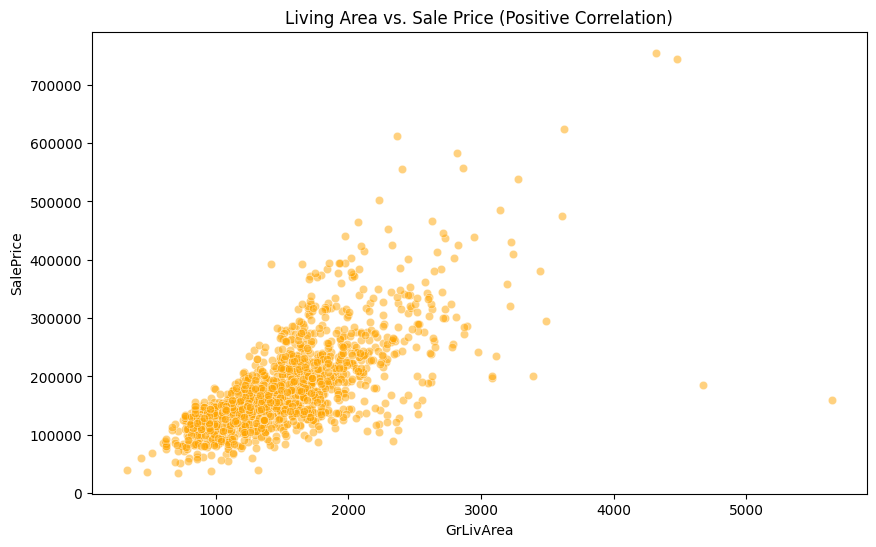

Correlation Coefficient:
           GrLivArea  SalePrice
GrLivArea   1.000000   0.708624
SalePrice   0.708624   1.000000


In [ ]:
# Step 4: Bivariate Analysis (Relationship between two variables)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df, color='orange', alpha=0.5)
plt.title("Living Area vs. Sale Price (Positive Correlation)")
plt.show()

# Show the actual math behind the relationship
correlation = df[['GrLivArea', 'SalePrice']].corr()
print("Correlation Coefficient:")
print(correlation)


### 5. **Checking for Outliers**
Finding extreme values that might break your model.

<Axes: xlabel='SalePrice'>

<Axes: xlabel='SalePrice'>

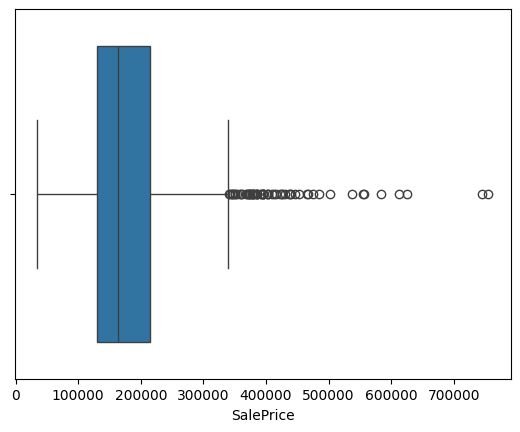

In [13]:
sns.boxplot(x=df['SalePrice']) # Look for dots outside the whiskers

## 2. Data Cleaning & Distribution Analysis
It's essential to understand the target variable's distribution.

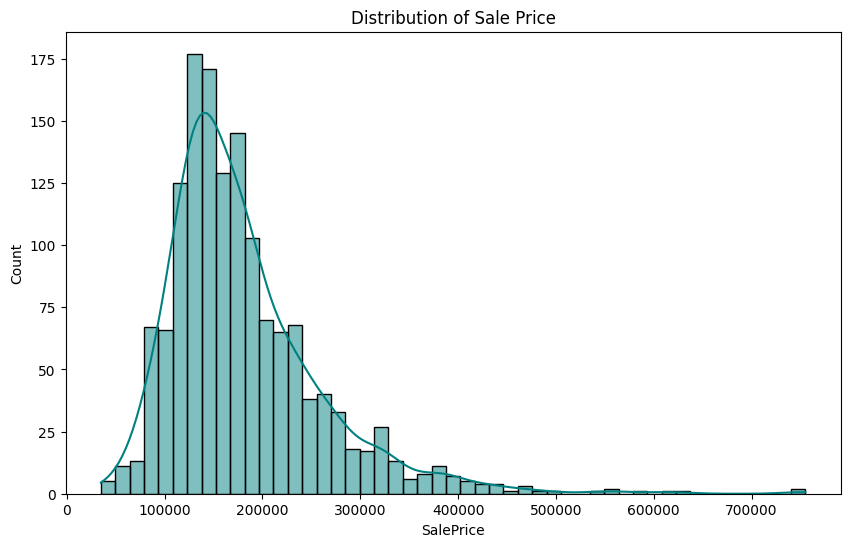

In [2]:
plt.figure(figsize=(10, 6))
sns.histplot(df['SalePrice'], kde=True, color='teal')
plt.title("Distribution of Sale Price")
plt.show()

### **Interpretation: The Histogram**
*   **The Peak:** Most houses are priced around $150k - $200k.
*   **Skewness:** Notice the "tail" on the right. A few very expensive luxury houses pull the average up. This is called **Right Skew**.


## 3. Multivariate Heatmap Analysis
Checking correlations between features.

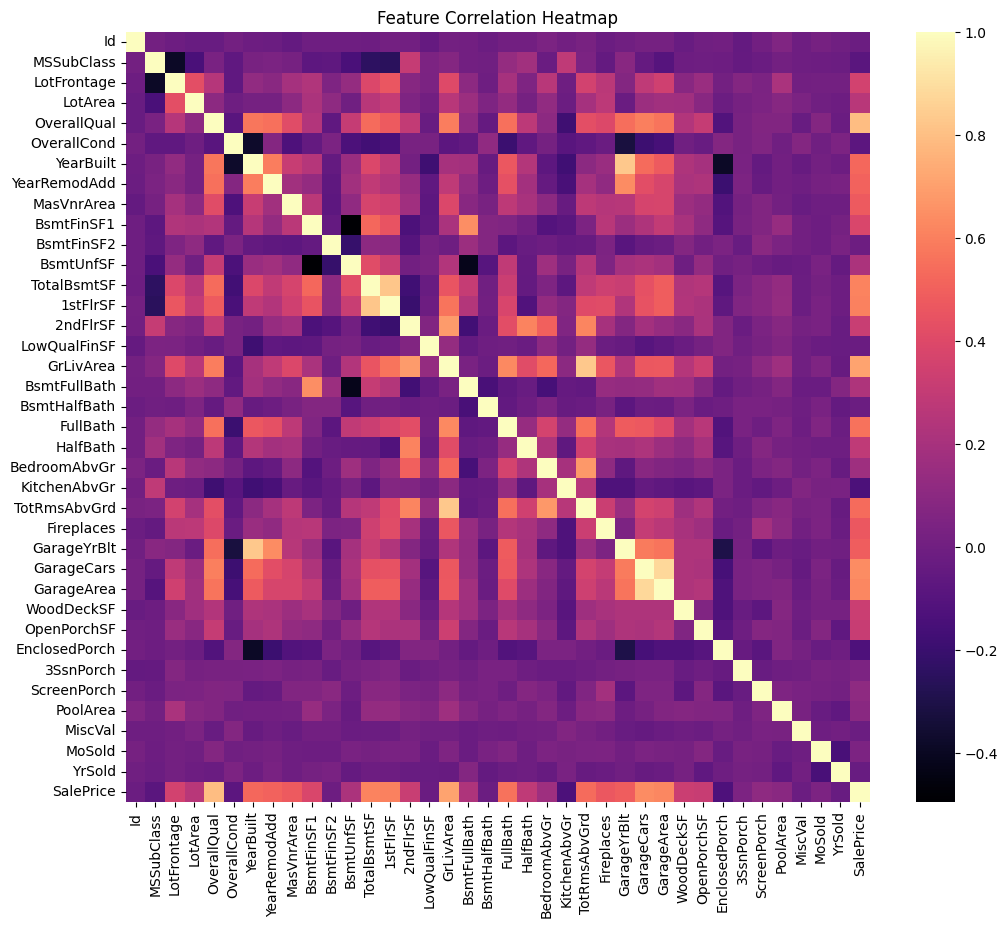

In [3]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='magma')
plt.title("Feature Correlation Heatmap")
plt.show()

### **Interpretation: The Heatmap**
*   **Correlation (0 to 1):** The closer to 1.0 (bright color), the stronger the relationship.
*   **Finding "Golden" Features:** We look for columns that have a high correlation with `SalePrice`. For example, `GrLivArea` (Living Area) usually has a very high score!


## 4. Relationship Discovery: Price vs Quality
How does 'OverallQual' affect 'SalePrice'?

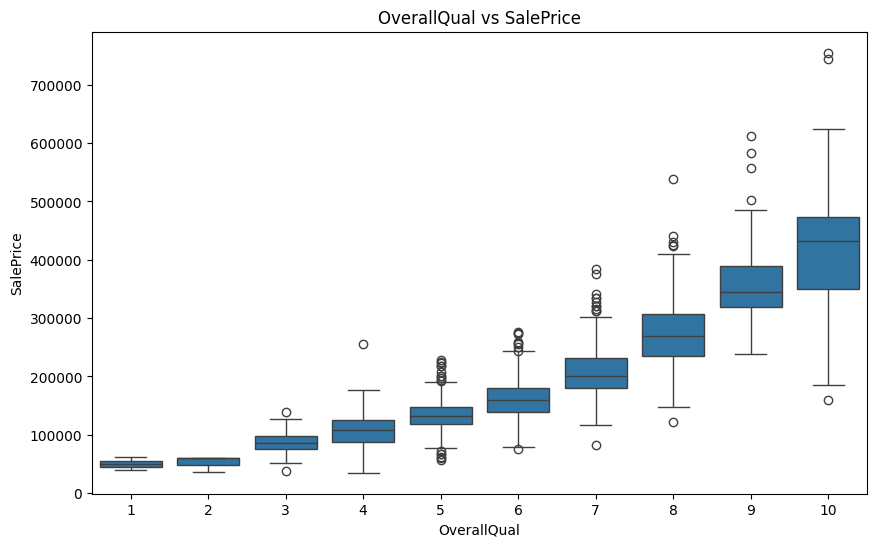

In [4]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='OverallQual', y='SalePrice', data=df)
plt.title("OverallQual vs SalePrice")
plt.show()

### **Interpretation: Boxplot (Quality vs Price)**
*   **The Boxes:** As the `OverallQual` (1 to 10) increases, the price clearly jumps up.
*   **The Dots (Outliers):** See the dots above the boxes? Those representing houses where the price is unusually high for that quality level.


## Hands-on Exercise
1. Sort features based on their correlation with SalePrice.
2. Perform a pairplot for the top 5 correlated features.

## Mini Project
Build a 'House Profile Tool' that provides the average price for different neighborhoods and property types (HouseStyle).